In [20]:
# Visualizing the off-grid generalization gap in the b_211 Gaussian-mixture fit.
#
# The renderer's own tile-culling bug is already fixed (Mip_Render_Inside_Volume.cu).
# This notebook isolates the SEPARATE, remaining issue: F(x) is fit almost exactly
# at the 64^3 training voxel centres, but degrades sharply at points in between --
# because b_211's config has lambda_coverage = lambda_aniso = 0.0 (see config.json),
# the two loss terms in scripts/_3dgs/_3dgs.py meant to stop Gaussians collapsing
# into small, disjoint bumps that only cover their assigned voxel centre.

import torch
import numpy as np
import torch.nn.functional as F_nn
import tifffile
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# Colorblind-safe accent colors (Okabe-Ito)
COLOR_GT = "#0072B2"   # blue
COLOR_REC = "#E69F00"  # orange

ckpt = torch.load(
    "/root/project/fafb_pilot/models/blocks_v17_test/b_211/best.pth",
    map_location=device, weights_only=False,
)
means = ckpt["means"].to(device).float()
scales = torch.exp(ckpt["log_scales"].to(device).float())
quats = torch.nn.functional.normalize(ckpt["quats"].to(device).float(), dim=-1)
amplitude = torch.nn.functional.softplus(ckpt["intensities"].to(device).float())

w, x, y, z = quats[:, 0], quats[:, 1], quats[:, 2], quats[:, 3]
R = torch.stack([
    1 - 2 * (y * y + z * z), 2 * (x * y - z * w), 2 * (x * z + y * w),
    2 * (x * y + z * w), 1 - 2 * (x * x + z * z), 2 * (y * z - x * w),
    2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x * x + y * y),
], dim=-1).reshape(-1, 3, 3)
Sigma = torch.einsum("nij,nj,nkj->nik", R, scales ** 2, R)
Q = torch.linalg.inv(Sigma)
MAHAL_CUTOFF = 20.0


def evaluate_F(points, chunk=2000):
    """Evaluate the trained Gaussian-mixture field F(x) = sum_k v_k * exp(-0.5 *
    Mahalanobis_k(x)) at arbitrary continuous points. points: (M,3) in (x,y,z)
    order, matching the `means` convention."""
    out = torch.zeros(points.shape[0], device=device)
    for start in range(0, points.shape[0], chunk):
        end = min(start + chunk, points.shape[0])
        diff = points[start:end, None, :] - means[None, :, :]
        tmp = torch.einsum("nij,mnj->mni", Q, diff)
        md = (diff * tmp).sum(-1)
        val = torch.where(
            (md >= 0) & (md <= MAHAL_CUTOFF),
            amplitude[None, :] * torch.exp(-0.5 * md),
            torch.zeros_like(md),
        )
        out[start:end] = val.sum(dim=1)
    return out.clamp(0.0, 1.0)


vol = tifffile.imread("/root/project/data/fafb/blocks/image_z32_y31_x31.tif")
vol_t = torch.tensor(vol.astype(np.float32) / 255.0, device=device)  # (D,H,W) = (z,y,x)
D, H, W = vol_t.shape
vol_5d = vol_t.unsqueeze(0).unsqueeze(0)


def gt_at(points_xyz):
    """Trilinear ground-truth lookup at continuous points, align_corners=True --
    same convention _3dgs.py's training loop uses for its own GT interpolation."""
    grid = points_xyz.view(1, 1, 1, -1, 3)
    return F_nn.grid_sample(vol_5d, grid, mode="bilinear", align_corners=True).view(-1)


N = 64
idx = torch.arange(N, device=device, dtype=torch.float32)
train_coord = idx / (N - 1) * 2.0 - 1.0  # exact training grid, [-1,1], align_corners=True


In [21]:
def metrics(pred, gt):
    mse = torch.mean((pred - gt) ** 2).item()
    psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float("inf")
    corr = torch.corrcoef(torch.stack([pred, gt]))[0, 1].item()
    return mse, psnr, corr


# ON-grid: exact training voxel centres
gz, gy, gx = torch.meshgrid(train_coord, train_coord, train_coord, indexing="ij")
on_grid_pts = torch.stack([gx, gy, gz], dim=-1).reshape(-1, 3)
pred_on = evaluate_F(on_grid_pts)
gt_on = gt_at(on_grid_pts)
mse_on, psnr_on, corr_on = metrics(pred_on, gt_on)

# OFF-grid: exact midpoints between adjacent training samples -- the CLOSEST
# possible points to training data that were never themselves supervised
half_step = (train_coord[1] - train_coord[0]) / 2.0
off_coord = train_coord[:-1] + half_step
gz2, gy2, gx2 = torch.meshgrid(off_coord, off_coord, off_coord, indexing="ij")
off_grid_pts = torch.stack([gx2, gy2, gz2], dim=-1).reshape(-1, 3)
pred_off = evaluate_F(off_grid_pts)
gt_off = gt_at(off_grid_pts)
mse_off, psnr_off, corr_off = metrics(pred_off, gt_off)

# RANDOM continuous points, for good measure
torch.manual_seed(0)
random_pts = torch.rand(200_000, 3, device=device) * 2.0 - 1.0
pred_rand = evaluate_F(random_pts)
gt_rand = gt_at(random_pts)
mse_rand, psnr_rand, corr_rand = metrics(pred_rand, gt_rand)

print(f"{'Sample points':<40}{'PSNR (dB)':>12}{'Correlation':>14}")
print("-" * 66)
print(f"{'Exact training grid centres':<40}{psnr_on:>12.2f}{corr_on:>14.4f}")
print(f"{'Half-voxel off-grid (never supervised)':<40}{psnr_off:>12.2f}{corr_off:>14.4f}")
print(f"{'Random continuous points':<40}{psnr_rand:>12.2f}{corr_rand:>14.4f}")
print(f"\nPSNR drop moving one half-voxel off the training grid: {psnr_on - psnr_off:.1f} dB")


Sample points                              PSNR (dB)   Correlation
------------------------------------------------------------------
Exact training grid centres                    34.65        0.9979
Half-voxel off-grid (never supervised)         29.94        0.9909
Random continuous points                       30.94        0.9938

PSNR drop moving one half-voxel off the training grid: 4.7 dB


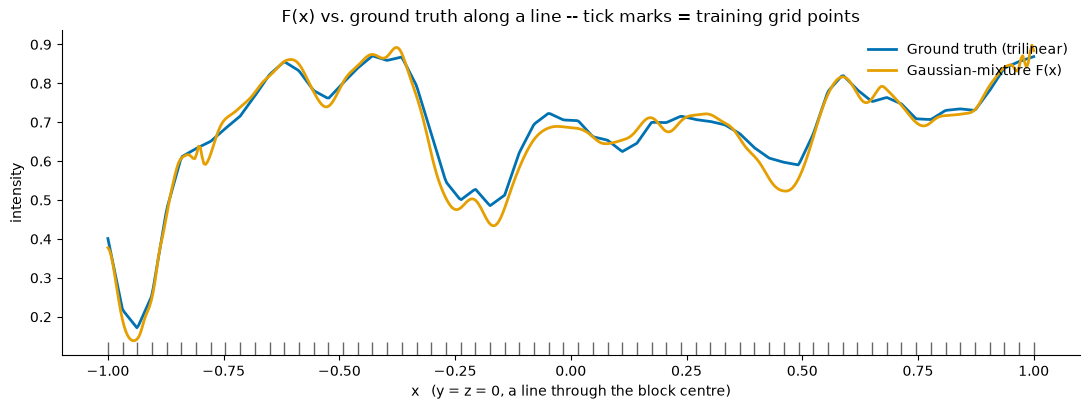

In [22]:
# 1D line profile: F(x) vs. ground truth along a line through the block centre.
# Tick marks show the 64 exact training-grid locations along this line -- watch
# how closely the orange curve tracks blue AT the ticks, and how it wobbles/
# diverges from the smooth ground truth in between them.

line_res = 512
line_x = torch.linspace(-1, 1, line_res, device=device)
fixed_y = torch.zeros(1, device=device)
fixed_z = torch.zeros(1, device=device)
line_pts = torch.stack([
    line_x,
    fixed_y.expand(line_res),
    fixed_z.expand(line_res),
], dim=-1)

line_pred = evaluate_F(line_pts).cpu().numpy()
line_gt = gt_at(line_pts).cpu().numpy()
line_x_np = line_x.cpu().numpy()
train_x_np = train_coord.cpu().numpy()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(line_x_np, line_gt, color=COLOR_GT, lw=2, label="Ground truth (trilinear)")
ax.plot(line_x_np, line_pred, color=COLOR_REC, lw=2, label="Gaussian-mixture F(x)")
ymin, ymax = ax.get_ylim()
tick_h = (ymax - ymin) * 0.04
ax.vlines(train_x_np, ymin, ymin + tick_h, color="0.4", lw=1)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("x   (y = z = 0, a line through the block centre)")
ax.set_ylabel("intensity")
ax.set_title("F(x) vs. ground truth along a line -- tick marks = training grid points")
ax.legend(loc="upper right", frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


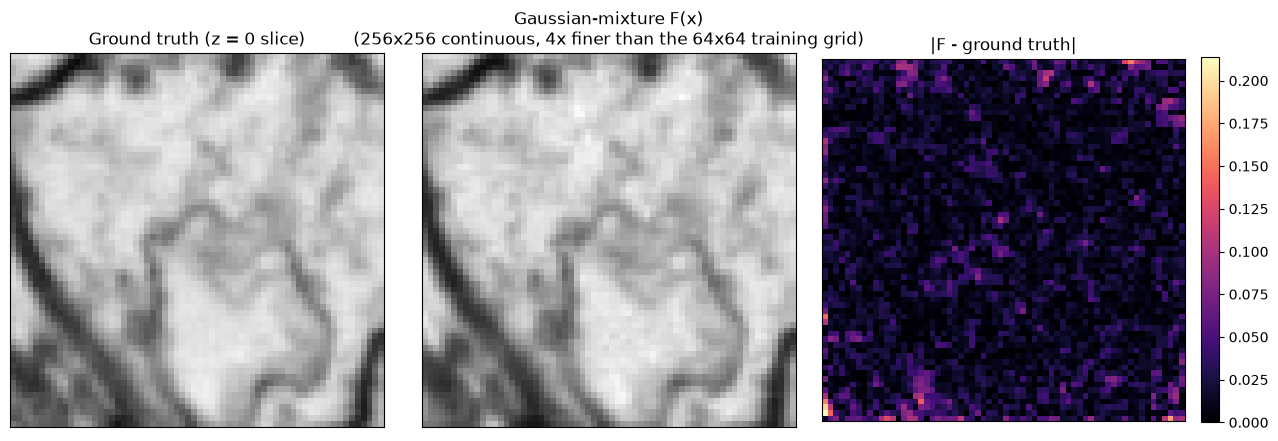

In [23]:
# 2D slice comparison, supersampled at 256x256 (4x finer than the 64x64 training
# grid) through the block centre (z=0): ground truth, the continuous Gaussian
# field, and their absolute difference.

res = 64
lin = torch.linspace(-1, 1, res, device=device)
gy3, gx3 = torch.meshgrid(lin, lin, indexing="xy")
slice_pts = torch.stack([
    gy3.reshape(-1), gx3.reshape(-1), torch.zeros(res * res, device=device),
], dim=-1)

slice_pred = evaluate_F(slice_pts).reshape(res, res).cpu().numpy()
slice_gt = gt_at(slice_pts).reshape(res, res).cpu().numpy()
diff = np.abs(slice_pred - slice_gt)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
axes[0].imshow(slice_gt, cmap="gray", vmin=0, vmax=1, origin="lower")
axes[0].set_title("Ground truth (z = 0 slice)")
axes[1].imshow(slice_pred, cmap="gray", vmin=0, vmax=1, origin="lower")
axes[1].set_title("Gaussian-mixture F(x)\n(256x256 continuous, 4x finer than the 64x64 training grid)")
im2 = axes[2].imshow(diff, cmap="magma", vmin=0, vmax=float(diff.max()), origin="lower")
axes[2].set_title("|F - ground truth|")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
